## Step 1: Import libraries

In [3]:
import pandas as pd

## Step 2: Load transformed dataset

In [4]:
# Load data from previous step
df = pd.read_csv("../data/processed/train_transformed.csv")

df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,1.791759,2.197225,1.791759,2.197225,1.945910,1.609438,1.609438,1.386294,1.386294,1.609438,...,1.791759,1.386294,1.386294,1.791759,1.609438,2.079442,1.791759,2.079442,1.386294,0.445
1,1.945910,2.079442,1.609438,1.609438,2.197225,2.197225,1.386294,1.791759,1.609438,1.945910,...,2.079442,1.098612,0.000000,1.386294,1.791759,1.386294,1.386294,1.609438,1.386294,0.450
2,1.945910,1.791759,1.945910,2.079442,1.386294,2.079442,0.693147,1.791759,1.609438,1.791759,...,2.079442,1.386294,2.079442,1.791759,1.945910,2.197225,1.098612,1.386294,1.386294,0.530
3,1.386294,1.609438,1.945910,1.791759,1.609438,2.197225,1.609438,2.079442,1.945910,2.197225,...,1.098612,1.609438,2.079442,1.609438,1.609438,1.945910,1.791759,2.079442,1.791759,0.535
4,1.791759,1.386294,1.098612,1.945910,1.609438,1.609438,1.386294,1.386294,1.386294,1.386294,...,1.098612,1.098612,1.945910,1.945910,1.609438,0.693147,1.098612,1.386294,1.791759,0.415


## Step 3: Drop irrelevant features

In [5]:
# Drop features not relevant for Nepal context
df = df.drop(["CoastalVulnerability", "PoliticalFactors"], axis=1)

## Step 4: Create new features (core logic)

In [6]:
# Rain and climate interaction
df["RainFactor"] = (
    df["MonsoonIntensity"] * df["ClimateChange"]
) 

# Land pressure from human activities
df["LandRisk"] = (
    df["Deforestation"] +
    df["Urbanization"] +
    df["Encroachments"]
) / 3

# Water management stress
df["WaterStress"] = (
    df["RiverManagement"] +
    df["DrainageSystems"] +
    df["DamsQuality"]
) / 3

# River/soil blockage factor
df["Blockage"] = (
    df["Siltation"] +
    df["Landslides"]
) / 2

## Step 5: Check dataset

In [5]:
# Check updated columns
df.columns



Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems', 'Landslides',
       'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore',
       'WetlandLoss', 'InadequatePlanning', 'FloodProbability', 'RainFactor',
       'LandRisk', 'WaterStress', 'Blockage'],
      dtype='str')

In [6]:
df.shape

(40000, 23)

## Step 7: Correlation check (after engineering)

ValueError: Format specifier missing precision

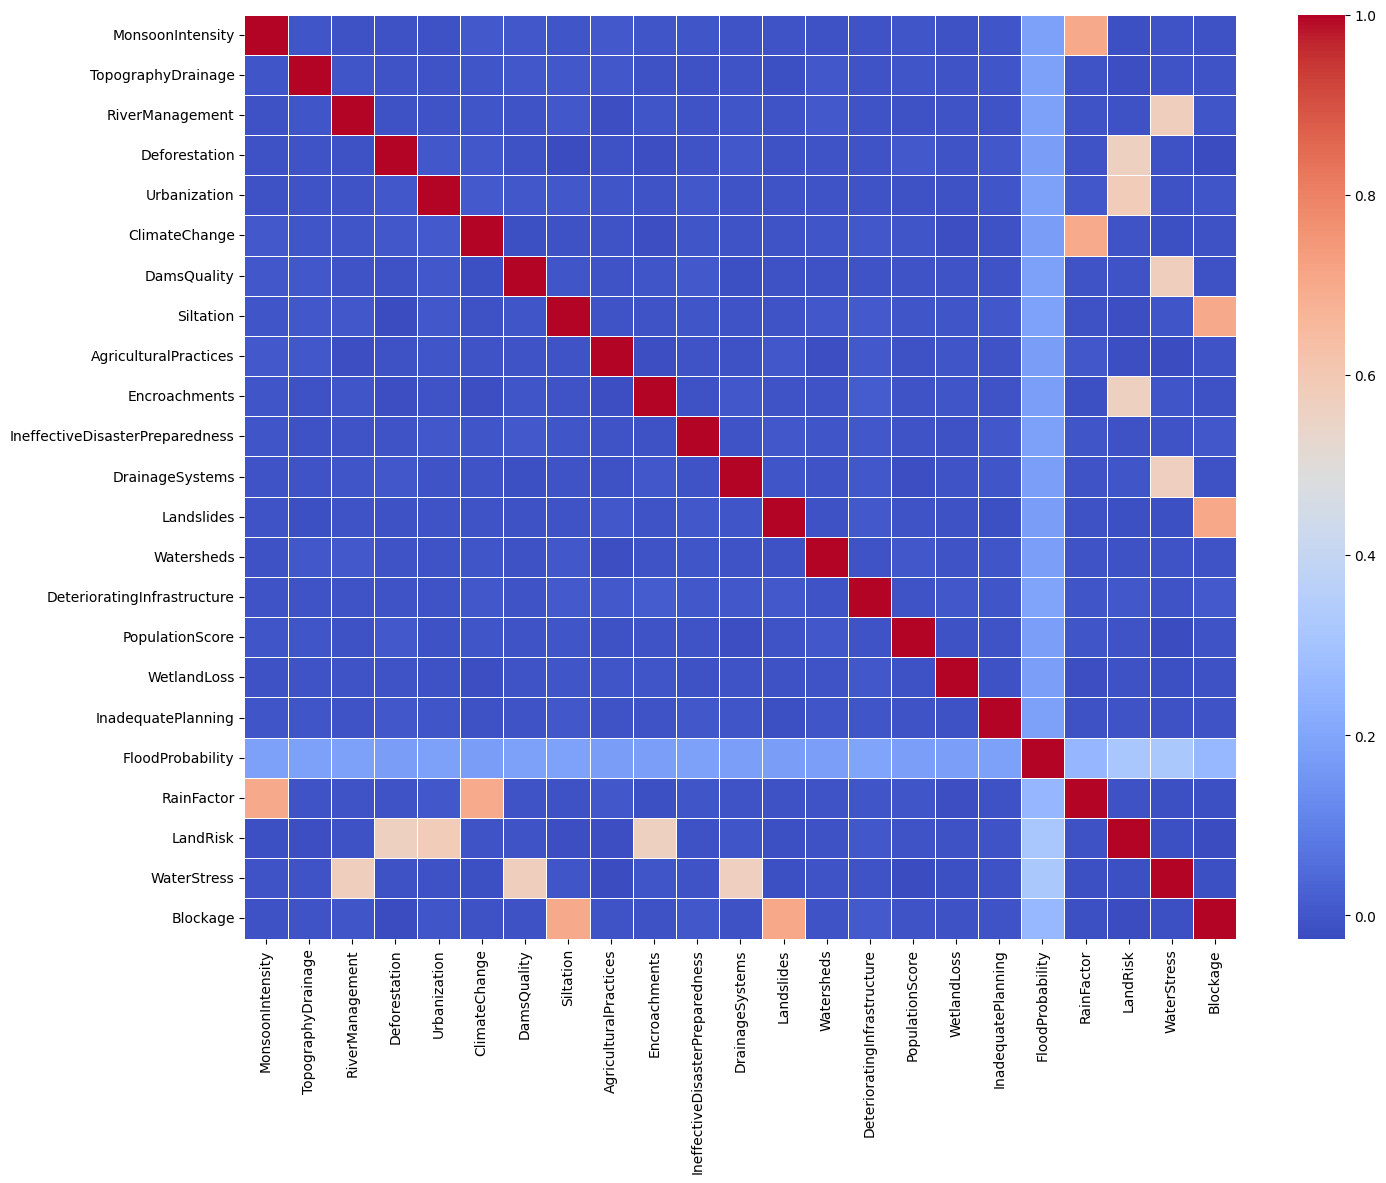

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title("Correlation Heatmap After Feature Engineering")
plt.show()

## Correlation with target

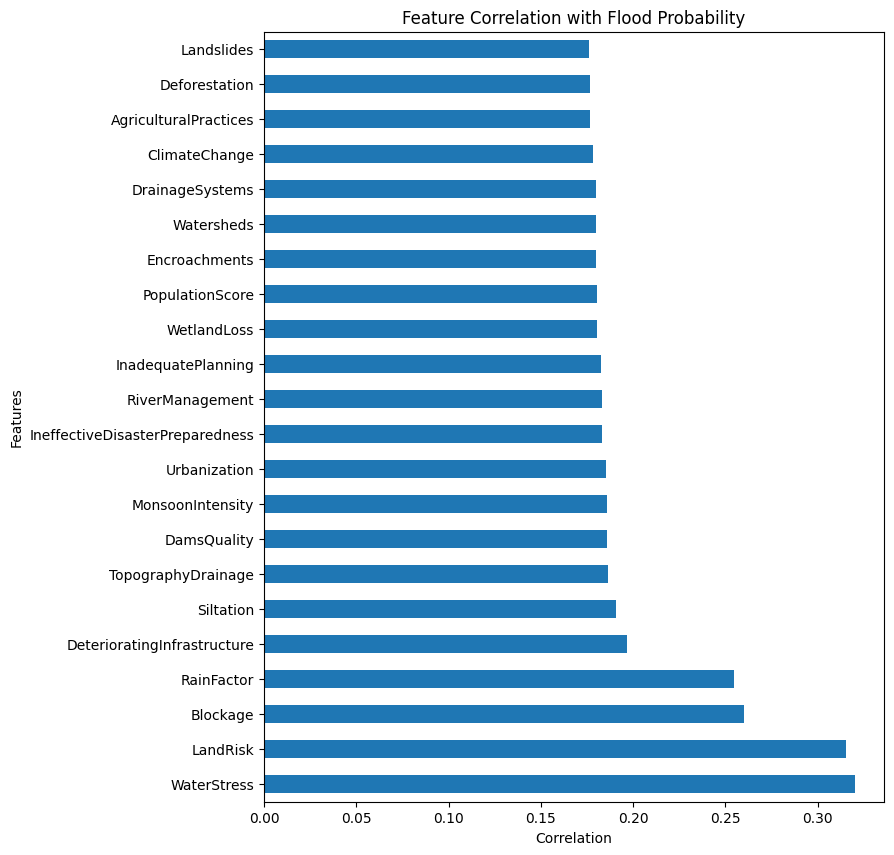

In [ ]:
target_corr = df.corr()["FloodProbability"].sort_values(ascending=False)

target_corr
plt.figure(figsize=(8,10))

target_corr.drop("FloodProbability").plot(kind="barh")

plt.title("Feature Correlation with Flood Probability")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

## Step 8: Save final dataset

In [8]:
import os

os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/train_final.csv", index=False)

print("Final feature engineered dataset saved successfully.")

Final feature engineered dataset saved successfully.


In [9]:
df.describe()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,FloodProbability,RainFactor,LandRisk,WaterStress,Blockage
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,...,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,1.711755,1.709284,1.718888,1.716016,1.714752,1.712451,1.713705,1.713925,1.717534,1.717750,...,1.707726,1.711331,1.711881,1.719294,1.717947,0.504572,2.931938,1.716173,1.716434,1.713067
std,0.381054,0.389671,0.384458,0.377898,0.384958,0.379376,0.388245,0.383094,0.382734,0.381958,...,0.389099,0.382289,0.383682,0.382043,0.382408,0.050844,0.931952,0.218231,0.220709,0.270563
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.320000,0.000000,0.462098,0.231049,0.000000
25%,1.386294,1.386294,1.609438,1.609438,1.386294,1.386294,1.386294,1.386294,1.609438,1.609438,...,1.386294,1.386294,1.386294,1.609438,1.386294,0.470000,2.284500,1.595831,1.595831,1.589027
50%,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,...,1.791759,1.791759,1.791759,1.791759,1.791759,0.505000,2.883726,1.730986,1.730986,1.732868
75%,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,...,1.945910,1.945910,1.945910,1.945910,1.945910,0.540000,3.536297,1.869824,1.869824,1.903331
max,2.833213,2.890372,2.833213,2.772589,2.833213,2.833213,2.772589,2.833213,2.833213,2.833213,...,2.833213,2.833213,2.890372,2.833213,2.833213,0.715000,6.946012,2.482584,2.427816,2.524928


In [10]:
df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,FloodProbability,RainFactor,LandRisk,WaterStress,Blockage
0,1.791759,2.197225,1.791759,2.197225,1.945910,1.609438,1.609438,1.386294,1.386294,1.609438,...,1.791759,1.609438,2.079442,1.791759,2.079442,0.445,2.883726,1.917524,1.730986,1.386294
1,1.945910,2.079442,1.609438,1.609438,2.197225,2.197225,1.386294,1.791759,1.609438,1.945910,...,1.386294,1.791759,1.386294,1.386294,1.609438,0.450,4.275602,1.917524,1.691725,0.895880
2,1.945910,1.791759,1.945910,2.079442,1.386294,2.079442,0.693147,1.791759,1.609438,1.791759,...,1.791759,1.945910,2.197225,1.098612,1.386294,0.530,4.046406,1.752498,1.572833,1.935601
3,1.386294,1.609438,1.945910,1.791759,1.609438,2.197225,1.609438,2.079442,1.945910,2.197225,...,1.609438,1.609438,1.945910,1.791759,2.079442,0.535,3.046000,1.866141,1.551320,2.079442
4,1.791759,1.386294,1.098612,1.945910,1.609438,1.609438,1.386294,1.386294,1.386294,1.386294,...,1.945910,1.609438,0.693147,1.098612,1.386294,0.415,2.883726,1.647214,1.194506,1.666102
